## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats
import numpy as np
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


## Development Permits Dataset

SOURCE: https://data.sandiego.gov/datasets/development-permits-set2/

DATASET DESCRIPTION
This combined dataset contains development permits issued by the City of San
Diego's Development Services Department, sourced from the city's cloud-based
permitting system (records begin 2018; legacy data predates that). Each row
represents a single permit approval linked to a parent project, and covers
activities such as new construction, additions, remodeling, and electrical,
mechanical, or plumbing system work. The two source files distinguish active
(in-progress or recently issued) permits from closed (completed or expired)
ones, which were merged into a single dataframe with a 'permit_status_category'
label column. Key fields include spatial coordinates, approval dates, project
valuation, permit type, processing priority, and affordability-tier breakdowns
for new dwelling units (DU) and accessory dwelling units (ADU/JADU).

Column Descriptions

| Column | Description |
|--------|-------------|
| `PROJECT_ID` | Unique ID for the parent project (one project → one or more approvals) |
| `JOB_ID` | Internal job identifier (often null in active records) |
| `APPROVAL_ID` | Unique permit/approval ID (e.g. PMT-3248638) |
| `PROJECT_TITLE` | Short human-readable title for the project |
| `PROJECT_SCOPE` | General description of the project's scope of work |
| `APPROVAL_SCOPE` | Specific scope description for this individual approval |
| `APPROVAL_TYPE` | Type of approval (e.g. Building Permit, Electrical Pmt, ADU) |
| `PROJECT_PROCESSING_CODE` | Project-level priority: Standard, Expedite, or Express |
| `APPROVAL_PROCESSING_CODE` | Approval-level priority: Standard, Expedite, or Express |
| `APPROVAL_STATUS` | Current status: Created, Issued, Completed, Closed, Cancelled, etc. |
| `JOB_BC_CODE` | Building code classification code |
| `JOB_BC_CODE_DESCRIPTION` | Human-readable description of the building code classification |
| `APPROVAL_PERMIT_HOLDER` | Name of the individual or company the permit is issued to |
| `ADDRESS_JOB` | Street address of the job site |
| `JOB_APN` | Assessor's Parcel Number — unique ID for a land parcel |
| `LAT_JOB` | Latitude of the primary job site location |
| `LNG_JOB` | Longitude of the primary job site location |
| `DATE_PROJECT_CREATE` | Date the parent project was created in the tracking system |
| `DATE_PROJECT_COMPLETE` | Legal date when submittal requirements were deemed complete |
| `DATE_APPROVAL_CREATE` | Date this approval/permit was added to the system |
| `DATE_APPROVAL_ISSUE` | Date the city granted permission to proceed |
| `DATE_APPROVAL_CLOSE` | Date the permit was closed (final inspection or expiry). Null = still active |
| `DATE_APPROVAL_EXPIRE` | Scheduled expiry date of the permit |
| `APPROVAL_VALUATION` | Estimated dollar value of the permitted work |
| `APPROVAL_STORIES` | Number of stories in the structure (where applicable) |
| `APPROVAL_FLOOR_AREA` | Total floor area in square feet (where applicable) |
| `APPROVAL_DU_EXTREMELY_LOW` | New dwelling units for households at <30% Area Median Income (AMI) |
| `APPROVAL_DU_VERY_LOW` | New dwelling units for households at 30–50% AMI |
| `APPROVAL_DU_LOW` | New dwelling units for households at 50–80% AMI |
| `APPROVAL_DU_MODERATE` | New dwelling units for households at 80–120% AMI |
| `APPROVAL_DU_ABOVE_MODERATE` | New dwelling units for households at >120% AMI |
| `APPROVAL_DU_BONUS` | Bonus dwelling units (density bonus law) |
| `APPROVAL_DU_FUTURE_DEMO` | Dwelling units flagged for future demolition |
| `APPROVAL_ADU_EXTREMELY_LOW` | ADU units at <30% AMI |
| `APPROVAL_ADU_VERY_LOW` | ADU units at 30–50% AMI |
| `APPROVAL_ADU_LOW` | ADU units at 50–80% AMI |
| `APPROVAL_ADU_MODERATE` | ADU units at 80–120% AMI |
| `APPROVAL_ADU_ABOVE_MODERATE` | ADU units at >120% AMI |
| `APPROVAL_ADU_BONUS` | Bonus ADU units |
| `APPROVAL_ADU_TOTAL` | Total ADU units across all affordability tiers |
| `APPROVAL_JADU_EXTREMELY_LOW` | Junior ADU units at <30% AMI |
| `APPROVAL_JADU_VERY_LOW` | Junior ADU units at 30–50% AMI |
| `APPROVAL_JADU_LOW` | Junior ADU units at 50–80% AMI |
| `APPROVAL_JADU_MODERATE` | Junior ADU units at 80–120% AMI |
| `APPROVAL_JADU_ABOVE_MODERATE` | Junior ADU units at >120% AMI |
| `APPROVAL_JADU_BONUS` | Bonus Junior ADU units |
| `APPROVAL_JADU_TOTAL` | Total Junior ADU units across all affordability tiers |


## Preprocessing of the Datasets

In [2]:
active_dev = pd.read_csv('data/permits_set2_active_dev.csv')
active_dev.head()

,PROJECT_ID,JOB_ID,APPROVAL_ID,PROJECT_TITLE,PROJECT_SCOPE,APPROVAL_SCOPE,APPROVAL_TYPE,PROJECT_PROCESSING_CODE,APPROVAL_PROCESSING_CODE,APPROVAL_STATUS,...,APPROVAL_ADU_ABOVE_MODERATE,APPROVAL_ADU_BONUS,APPROVAL_ADU_TOTAL,APPROVAL_JADU_EXTREMELY_LOW,APPROVAL_JADU_VERY_LOW,APPROVAL_JADU_LOW,APPROVAL_JADU_MODERATE,APPROVAL_JADU_ABOVE_MODERATE,APPROVAL_JADU_BONUS,APPROVAL_JADU_TOTAL
0,NaN,NaN,PMT-3248638,NaN,NaN,NaN,Photovoltaic - SB 379,NaN,NaN,Issued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,PMT-3241252,NaN,NaN,NaN,Photovoltaic - SB 379,NaN,NaN,Inspection Followup,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,PMT-3281343,NaN,NaN,NaN,Photovoltaic - SB 379,NaN,NaN,Issued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,PMT-3293015,NaN,NaN,NaN,Photovoltaic - SB 379,NaN,NaN,Cancelled,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,PMT-3270379,NaN,NaN,NaN,Photovoltaic - SB 379,NaN,NaN,Issued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ----------------------------------------------------------
# Inspection of Shape, DTypes, Missing Values
# ----------------------------------------------------------
print("Shape:", active_dev.shape)
print("\nDtypes:\n", active_dev.dtypes)
print("\nMissing values (%):\n",
      (active_dev.isnull().mean() * 100).round(2).sort_values(ascending=False))

Shape: (255743, 47)

Dtypes:
 PROJECT_ID                       object
JOB_ID                           object
APPROVAL_ID                      object
PROJECT_TITLE                    object
PROJECT_SCOPE                    object
APPROVAL_SCOPE                   object
APPROVAL_TYPE                    object
PROJECT_PROCESSING_CODE          object
APPROVAL_PROCESSING_CODE         object
APPROVAL_STATUS                  object
JOB_BC_CODE                     float64
JOB_BC_CODE_DESCRIPTION          object
APPROVAL_PERMIT_HOLDER           object
ADDRESS_JOB                      object
JOB_APN                          object
LAT_JOB                         float64
LNG_JOB                         float64
DATE_PROJECT_CREATE              object
DATE_PROJECT_COMPLETE            object
DATE_APPROVAL_CREATE             object
DATE_APPROVAL_ISSUE              object
DATE_APPROVAL_CLOSE             float64
DATE_APPROVAL_EXPIRE             object
APPROVAL_VALUATION              float64
APPROVAL_S

In [3]:
closed_dev = pd.read_csv('data/permits_set2_closed_dev.csv')
closed_dev.head()

,PROJECT_ID,JOB_ID,APPROVAL_ID,PROJECT_TITLE,PROJECT_SCOPE,APPROVAL_SCOPE,APPROVAL_TYPE,PROJECT_PROCESSING_CODE,APPROVAL_PROCESSING_CODE,APPROVAL_STATUS,...,APPROVAL_ADU_ABOVE_MODERATE,APPROVAL_ADU_BONUS,APPROVAL_ADU_TOTAL,APPROVAL_JADU_EXTREMELY_LOW,APPROVAL_JADU_VERY_LOW,APPROVAL_JADU_LOW,APPROVAL_JADU_MODERATE,APPROVAL_JADU_ABOVE_MODERATE,APPROVAL_JADU_BONUS,APPROVAL_JADU_TOTAL
0,PRJ-1020858,NaN,PMT-3065902,Project - Residential - Photo-voltaic:15748/Vi...,Pro Cert - Roof PV,Pro Cert - Roof PV,Approval - Construction - Electrical Pmt - PV ...,NaN,NaN,Closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PRJ-1022185,NaN,PMT-3070399,Project - Residential - Photo-voltaic:8037/New...,"PV Residential Roof Mount 4.875kW, 15 modules ...","PV Residential Roof Mount 4.875kW, 15 modules ...",Approval - Construction - Electrical Pmt - PV ...,NaN,NaN,Closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PRJ-1022688,NaN,PMT-3072243,Project - Residential - Photo-voltaic:7265/Sky...,"PV Resindetial Roof Mount 2.880kW, 9 Modules &...","PV Resindetial Roof Mount 2.880kW, 9 Modules &...",Approval - Construction - Electrical Pmt - PV ...,NaN,NaN,Closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PRJ-1027022,NaN,PMT-3084521,Project - Residential - Photo-voltaic:7718/Cam...,Pro Cert - Roof PV,Pro Cert - Roof PV,Approval - Construction - Electrical Pmt - PV ...,NaN,NaN,Closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PRJ-1027267,NaN,PMT-3085072,Project - Residential - Photo-voltaic:5239/Top...,Install 7.48kW roof mounted solar system with ...,Install 7.48kW roof mounted solar system with ...,Approval - Construction - Electrical Pmt - PV ...,NaN,NaN,Closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ----------------------------------------------------------
# Inspection of Shape, DTypes, Missing Values
# ----------------------------------------------------------
print("Shape:", closed_dev.shape)
print("\nDtypes:\n", closed_dev.dtypes)
print("\nMissing values (%):\n",
      (closed_dev.isnull().mean() * 100).round(2).sort_values(ascending=False))

Shape: (132550, 47)

Dtypes:
 PROJECT_ID                       object
JOB_ID                           object
APPROVAL_ID                      object
PROJECT_TITLE                    object
PROJECT_SCOPE                    object
APPROVAL_SCOPE                   object
APPROVAL_TYPE                    object
PROJECT_PROCESSING_CODE          object
APPROVAL_PROCESSING_CODE         object
APPROVAL_STATUS                  object
JOB_BC_CODE                     float64
JOB_BC_CODE_DESCRIPTION          object
APPROVAL_PERMIT_HOLDER           object
ADDRESS_JOB                      object
JOB_APN                          object
LAT_JOB                         float64
LNG_JOB                         float64
DATE_PROJECT_CREATE              object
DATE_PROJECT_COMPLETE            object
DATE_APPROVAL_CREATE             object
DATE_APPROVAL_ISSUE              object
DATE_APPROVAL_CLOSE              object
DATE_APPROVAL_EXPIRE             object
APPROVAL_VALUATION              float64
APPROVAL_S

## Merging to 1 Dataset

In [8]:
# Merging to 1 Dataset

# Active / Closed Category
active_dev['permit_status_category'] = 'Active'
closed_dev['permit_status_category'] = 'Closed'

df = pd.concat([active_dev, closed_dev], ignore_index=True)
print(f"\nCombined shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Combined shape: 388,293 rows × 48 columns


In [9]:
# full data cleaning

#standardizing 
df.columns = df.columns.str.strip().str.upper()

# date columns
date_cols = [
    'DATE_PROJECT_CREATE', 'DATE_PROJECT_COMPLETE',
    'DATE_APPROVAL_CREATE', 'DATE_APPROVAL_ISSUE',
    'DATE_APPROVAL_CLOSE',  'DATE_APPROVAL_EXPIRE',
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("\nDate columns parsed:")
for col in date_cols:
    if col in df.columns:
        nulls = df[col].isna().sum()
        print(f"  {col:<30} nulls: {nulls:,}")

# getting useful date features
df['issue_year']  = df['DATE_APPROVAL_ISSUE'].dt.year
df['issue_month'] = df['DATE_APPROVAL_ISSUE'].dt.month
df['issue_quarter'] = df['DATE_APPROVAL_ISSUE'].dt.to_period('Q').astype(str)

# days from creation to issuance (approval lead time)
df['days_to_issue'] = (
    df['DATE_APPROVAL_ISSUE'] - df['DATE_APPROVAL_CREATE']
).dt.days

# days permit was open (issue → close); NaN for still-active permits
df['days_open'] = (
    df['DATE_APPROVAL_CLOSE'] - df['DATE_APPROVAL_ISSUE']
).dt.days

print("\nDerived columns added: issue_year, issue_month, issue_quarter, "
      "days_to_issue, days_open")

# cleaned numeric columns
numeric_cols = [
    'APPROVAL_VALUATION', 'APPROVAL_STORIES', 'APPROVAL_FLOOR_AREA',
    'APPROVAL_ADU_TOTAL', 'APPROVAL_JADU_TOTAL',
    'APPROVAL_DU_EXTREMELY_LOW', 'APPROVAL_DU_VERY_LOW',
    'APPROVAL_DU_LOW', 'APPROVAL_DU_MODERATE', 'APPROVAL_DU_ABOVE_MODERATE',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# strip whitespace from string columns 
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip() if s.dtype == 'object' else s)

# standardize APPROVAL_STATUS casing 
if 'APPROVAL_STATUS' in df.columns:
    df['APPROVAL_STATUS'] = df['APPROVAL_STATUS'].str.title()

# extract ZIP code from address 
if 'ADDRESS_JOB' in df.columns:
    df['zip_code'] = df['ADDRESS_JOB'].str.extract(r'(\d{5})(?:-\d{4})?$')

# remove obvious geo outliers 
# San Diego bounding box: lat 32.5–33.2, lng -117.4 – -116.7
if 'LAT_JOB' in df.columns and 'LNG_JOB' in df.columns:
    geo_mask = (
        df['LAT_JOB'].between(32.5, 33.2) &
        df['LNG_JOB'].between(-117.4, -116.7)
    )
    removed = (~geo_mask & df['LAT_JOB'].notna()).sum()
    print(f"\nGeo outliers removed: {removed:,}")
    df = df[geo_mask | df['LAT_JOB'].isna()].reset_index(drop=True)



Date columns parsed:
  DATE_PROJECT_CREATE            nulls: 218,450
  DATE_PROJECT_COMPLETE          nulls: 225,339
  DATE_APPROVAL_CREATE           nulls: 0
  DATE_APPROVAL_ISSUE            nulls: 66,250
  DATE_APPROVAL_CLOSE            nulls: 255,743
  DATE_APPROVAL_EXPIRE           nulls: 183,550

Derived columns added: issue_year, issue_month, issue_quarter, days_to_issue, days_open

Geo outliers removed: 18


In [10]:
# missing values summary
print("\nMISSING VALUE SUMMARY (columns with any nulls)")
print("─" * 50)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
print(missing_df.to_string())


MISSING VALUE SUMMARY (columns with any nulls)
──────────────────────────────────────────────────
                              Missing  Pct (%)
APPROVAL_DU_FUTURE_DEMO        384307     99.0
APPROVAL_FLOOR_AREA            374633     96.5
APPROVAL_STORIES               372657     96.0
APPROVAL_ADU_TOTAL             360770     92.9
APPROVAL_JADU_TOTAL            360770     92.9
APPROVAL_JADU_LOW              360750     92.9
APPROVAL_ADU_LOW               360750     92.9
APPROVAL_ADU_VERY_LOW          360750     92.9
APPROVAL_ADU_EXTREMELY_LOW     360750     92.9
APPROVAL_ADU_BONUS             360750     92.9
APPROVAL_ADU_ABOVE_MODERATE    360750     92.9
APPROVAL_JADU_EXTREMELY_LOW    360750     92.9
APPROVAL_JADU_VERY_LOW         360750     92.9
APPROVAL_ADU_MODERATE          360750     92.9
APPROVAL_JADU_MODERATE         360750     92.9
APPROVAL_JADU_ABOVE_MODERATE   360750     92.9
APPROVAL_JADU_BONUS            360750     92.9
APPROVAL_VALUATION             359084     92.5
APPROVAL

In [11]:
# summary descriptive stats
print("\n\nDESCRIPTIVE STATISTICS — Numeric Columns")
print("─" * 50)
print(df[numeric_cols].describe().round(2).to_string())



DESCRIPTIVE STATISTICS — Numeric Columns
──────────────────────────────────────────────────
       APPROVAL_VALUATION  APPROVAL_STORIES  APPROVAL_FLOOR_AREA  APPROVAL_ADU_TOTAL  APPROVAL_JADU_TOTAL  APPROVAL_DU_EXTREMELY_LOW  APPROVAL_DU_VERY_LOW  APPROVAL_DU_LOW  APPROVAL_DU_MODERATE  APPROVAL_DU_ABOVE_MODERATE
count        2.919100e+04          15618.00             13642.00            27505.00             27505.00                   30450.00              30549.00         30547.00              30554.00                    30567.00
mean         3.500408e+07              1.54              1202.79                0.36                 0.02                       0.01                  0.07             0.09                  0.05                        0.85
std          5.853009e+09              2.29             19946.03                1.32                 0.16                       0.59                  1.58             2.59                  1.43                       14.41
min          0.000

## Exploratory Data Analysis

In [13]:
## plot styling
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

BLUE   = '#2563eb'
GRAY   = '#64748b'
AMBER  = '#f59e0b'
GREEN  = '#16a34a'
RED    = '#dc2626'

### Permit Volume by Year (active vs closed)

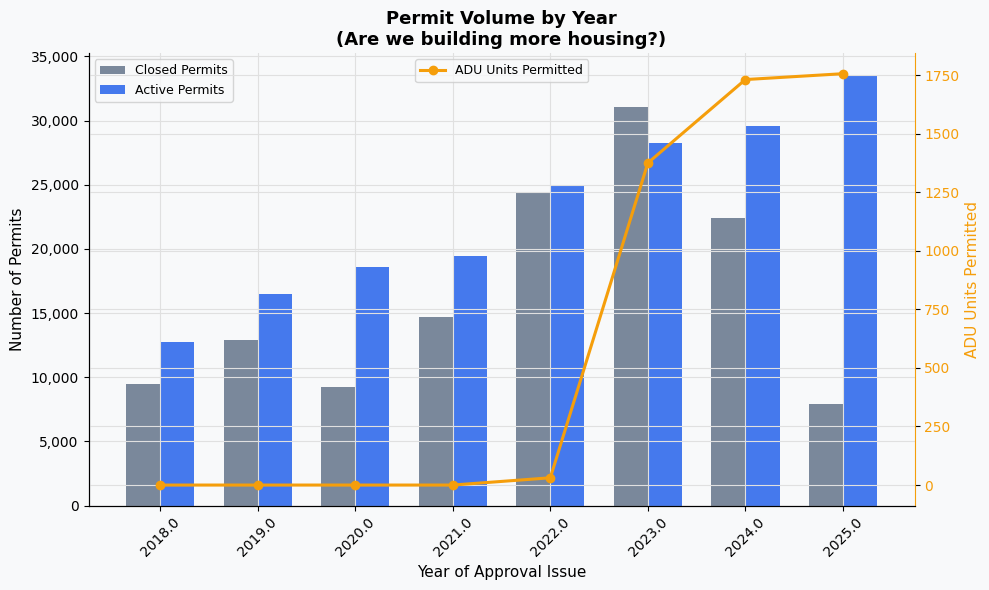

In [19]:
# ── CHART 1 — Permit Volume by Year (Active vs Closed) + ADU trend
# Question: Is permit activity growing? Are ADUs accelerating?

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

if 'issue_year' in df.columns:
    yr_status = (
        df[df['issue_year'].between(2018, 2025)]
        .groupby(['issue_year', 'PERMIT_STATUS_CATEGORY'])
        .size()
        .unstack(fill_value=0)
    )

    adu_col = 'APPROVAL_ADU_TOTAL' if 'APPROVAL_ADU_TOTAL' in df.columns else None
    if adu_col:
        adu_by_year = (
            df[df['issue_year'].between(2018, 2025)]
            .groupby('issue_year')[adu_col]
            .sum()
        )

    x = yr_status.index
    width = 0.35
    x_pos = np.arange(len(x))

    if 'Closed' in yr_status.columns:
        ax1.bar(x_pos - width/2, yr_status['Closed'], width,
                label='Closed Permits', color=GRAY, alpha=0.85)
    if 'Active' in yr_status.columns:
        ax1.bar(x_pos + width/2, yr_status['Active'], width,
                label='Active Permits', color=BLUE, alpha=0.85)

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x, rotation=45)

    if adu_col:
        ax1_r = ax1.twinx()
        ax1_r.plot(x_pos, adu_by_year.values, color=AMBER,
                   marker='o', linewidth=2.2, label='ADU Units Permitted', zorder=5)
        ax1_r.set_ylabel('ADU Units Permitted', color=AMBER)
        ax1_r.tick_params(axis='y', labelcolor=AMBER)
        ax1_r.spines['right'].set_visible(True)
        ax1_r.spines['right'].set_color(AMBER)
        ax1.legend(loc='upper left', fontsize=9)
        ax1_r.legend(loc='upper center', fontsize=9)
    else:
        ax1.legend(fontsize=9)

ax1.set_title("Permit Volume by Year\n(Are we building more housing?)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Year of Approval Issue")
ax1.set_ylabel("Number of Permits")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Interpretation: 
The spike in active permits in 2025 most likely reflects a **data recency bias** — 
permits issued recently have not yet had sufficient time to close, so they remain 
in "active" status. This is expected and should not be read as a surge in new activity.

The ADU trend is more substantive: ADU permitting grew rapidly following California's 
2019–2020 legislative reforms but has plateaued since 2022, suggesting that permitting 
barriers have been largely addressed while structural constraints (cost, financing, 
lot availability) now limit further growth — a key bottleneck in San Diego's broader 
housing supply response.

### Top Permit Types by Count

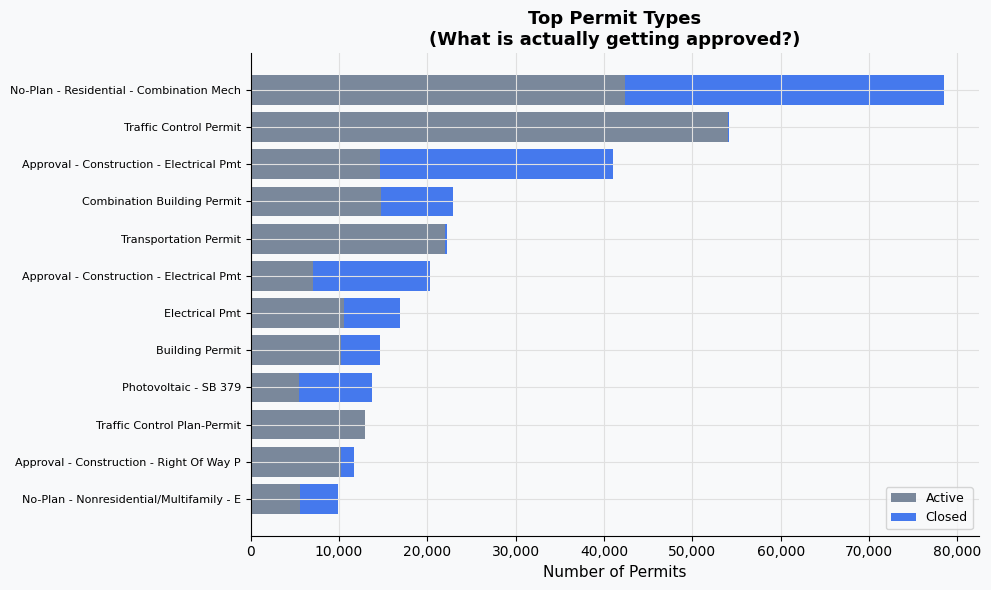

In [20]:
# ── CHART 2 — Top Permit Types by Count (stacked Active vs Closed)
# Question: What types of permits dominate — are housing permits a priority?

fig, ax2 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

if 'APPROVAL_TYPE' in df.columns:
    top_types = df['APPROVAL_TYPE'].value_counts().head(12).index
    type_status = (
        df[df['APPROVAL_TYPE'].isin(top_types)]
        .groupby(['APPROVAL_TYPE', 'PERMIT_STATUS_CATEGORY'])
        .size()
        .unstack(fill_value=0)
    )
    type_status['_total'] = type_status.sum(axis=1)
    type_status = type_status.sort_values('_total').drop('_total', axis=1)

    labels = [t[:40] for t in type_status.index]
    y_pos = np.arange(len(labels))

    left = np.zeros(len(labels))
    for col, color in zip(type_status.columns, [GRAY, BLUE]):
        ax2.barh(y_pos, type_status[col], left=left,
                 color=color, alpha=0.85, label=col)
        left += type_status[col].values

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=8)
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.legend(fontsize=9)

ax2.set_title("Top Permit Types\n(What is actually getting approved?)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Number of Permits")
plt.tight_layout()
plt.show()

Interpretation:
Among the top permit types, **construction permits dominate** in total volume, yet a 
notable share remain active (i.e. not yet closed), suggesting a healthy and ongoing 
pipeline of construction activity in San Diego.

However, the most concerning finding is for **Residential Building Permits** — despite 
being one of the highest-volume permit types, roughly half appear to still be in active 
status rather than closed/completed. This could indicate one of two things: either 
residential projects take significantly longer to complete than other permit types, or 
there is a growing backlog of residential permits that are being issued but not reaching 
completion — both of which are troubling signals in the context of a housing shortage.

In contrast, permit types like **solar/photovoltaic and electrical permits** show a much 
higher proportion of closed permits, meaning those projects move through the pipeline 
faster and more predictably. The disparity between how efficiently simpler permits close 
versus how slowly residential construction completes points to a **systemic bottleneck 
in housing delivery** — permits are being granted, but the housing units are not 
materializing at the same pace. For a city facing a severe housing crisis, the gap 
between approval and completion is just as critical as the approval rate itself.

### New Housing Units by Affordability Tier

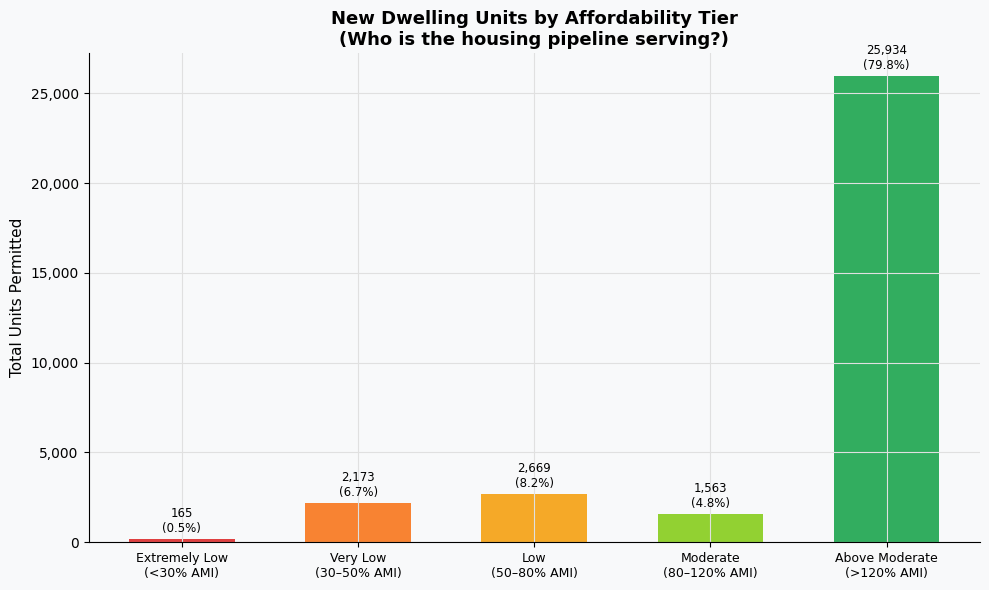

In [21]:
# ── CHART 3 — New Housing Units by Affordability Tier
# Question: Who is the new housing being built for?

fig, ax3 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

du_cols = {
    'Extremely Low\n(<30% AMI)':  'APPROVAL_DU_EXTREMELY_LOW',
    'Very Low\n(30–50% AMI)':     'APPROVAL_DU_VERY_LOW',
    'Low\n(50–80% AMI)':          'APPROVAL_DU_LOW',
    'Moderate\n(80–120% AMI)':    'APPROVAL_DU_MODERATE',
    'Above Moderate\n(>120% AMI)':'APPROVAL_DU_ABOVE_MODERATE',
}

present_du = {k: v for k, v in du_cols.items() if v in df.columns}
du_totals = {label: df[col].sum(skipna=True) for label, col in present_du.items()}

colors_affordability = [RED, '#f97316', AMBER, '#84cc16', GREEN]
labels_af = list(du_totals.keys())
values_af = list(du_totals.values())

bars = ax3.bar(range(len(labels_af)), values_af,
               color=colors_affordability[:len(labels_af)], alpha=0.88, width=0.6)
ax3.set_xticks(range(len(labels_af)))
ax3.set_xticklabels(labels_af, fontsize=9, ha='center')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

total_units = sum(values_af)
for bar, val in zip(bars, values_af):
    if total_units > 0:
        pct = val / total_units * 100
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values_af)*0.01,
                 f'{int(val):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5)

ax3.set_title("New Dwelling Units by Affordability Tier\n(Who is the housing pipeline serving?)", fontsize=13, fontweight='bold')
ax3.set_ylabel("Total Units Permitted")
plt.tight_layout()
plt.show()

Interpretation:
An overwhelming **~80% of all newly permitted dwelling units** fall into the 
**Above Moderate income category (>120% AMI)**, meaning the vast majority of 
new housing being built in San Diego is priced for higher-income households. 
Units affordable to Extremely Low, Very Low, and Low income households together 
represent only a fraction of the total pipeline. This is a stark reflection of 
San Diego's housing affordability crisis — the city consistently ranks as one of 
the least affordable markets in the U.S., yet the development pipeline is 
overwhelmingly serving those who need help the least. This skew is largely 
structural: developers respond to market incentives, and market-rate or luxury 
housing generates far higher returns than affordable units, which typically require 
public subsidies or inclusionary zoning mandates to be financially viable. Without 
a deliberate policy shift, the gap between who San Diego is building for and who 
actually needs housing will continue to widen.

### Permit Approval Lead Time

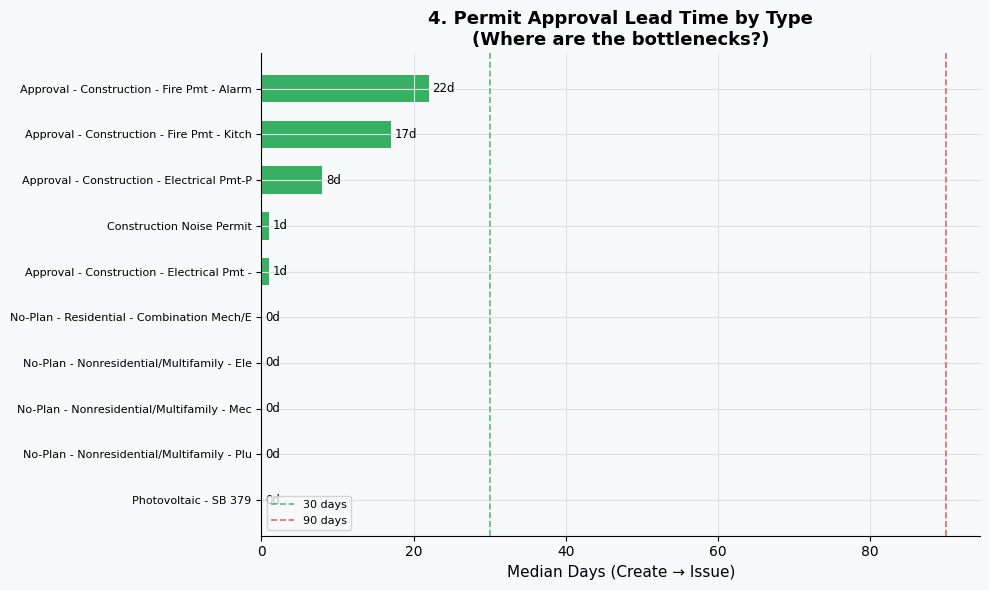

In [22]:
# ── CHART 4 — Permit Approval Lead Time: days from create → issue
# Question: How long does the permitting process take? Where are the bottlenecks?

fig, ax4 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

if 'days_to_issue' in df.columns and 'APPROVAL_TYPE' in df.columns:
    housing_keywords = ['Residential', 'ADU', 'Addition', 'Construction',
                        'Building', 'Tenant', 'Photovoltaic', 'Solar']
    mask = df['APPROVAL_TYPE'].str.contains('|'.join(housing_keywords), case=False, na=False)
    plot_df = df[mask] if mask.sum() > 50 else df

    median_lead = (
        plot_df[plot_df['days_to_issue'].between(0, 730)]
        .groupby('APPROVAL_TYPE')['days_to_issue']
        .median()
        .sort_values(ascending=True)
        .head(10)
    )

    colors_lead = [GREEN if v <= 30 else AMBER if v <= 90 else RED
                   for v in median_lead.values]
    bars4 = ax4.barh(range(len(median_lead)),
                     median_lead.values,
                     color=colors_lead, alpha=0.85, height=0.6)
    ax4.set_yticks(range(len(median_lead)))
    ax4.set_yticklabels([t[:42] for t in median_lead.index], fontsize=8)

    for bar, val in zip(bars4, median_lead.values):
        ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{int(val)}d', va='center', fontsize=8.5)

    ax4.axvline(30, color=GREEN, linestyle='--', linewidth=1.2, alpha=0.7, label='30 days')
    ax4.axvline(90, color=RED,   linestyle='--', linewidth=1.2, alpha=0.7, label='90 days')
    ax4.legend(fontsize=8)
    ax4.set_xlabel("Median Days (Create → Issue)")

ax4.set_title("4. Permit Approval Lead Time by Type\n(Where are the bottlenecks?)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Interpretation:
Construction-related permits — such as residential building, additions, and tenant 
improvements — have the longest median approval lead times, ranging from roughly 
**8 to 22 days** from creation to issuance, while simpler permit types like 
solar/photovoltaic approvals resolve in near zero days. This gap reflects the 
inherently greater complexity of construction permits, which require more thorough 
plan review, inspections, and regulatory scrutiny before the city can grant approval. 
While these lead times may appear short in isolation, they compound significantly 
when combined with construction timelines, financing delays, and contractor 
availability — all of which slow the delivery of new housing units. In the context 
of San Diego's housing crisis, even modest bureaucratic delays in the permitting 
pipeline can push project timelines out by months, discouraging smaller developers 
and homeowners from pursuing new housing projects altogether.

## Key Takeaway from this Dataset

San Diego's development permit pipeline reveals a system that is **approving housing 
but not delivering it equitably or fast enough** to meet the city's affordability 
crisis. The overwhelming majority (~80%) of new units are built for above-moderate 
income households, leaving low- and extremely-low income residents with almost no 
new housing supply. While ADU permits surged following California's 2019–2020 
reforms, growth has plateaued — suggesting policy wins alone are no longer enough 
and that cost and financing barriers now dominate. Residential construction permits 
also show a significant backlog of active-but-unclosed permits, meaning approvals 
are not reliably translating into completed housing units. Taken together, the data 
makes clear that San Diego's housing crisis is not just a shortage of permits — it 
is a shortage of **affordable, completed units** — and closing that gap will require 
targeted subsidies, stronger inclusionary zoning, and faster pathways for residential 
construction completion.